# PySpark DataFrame Set Operations

## Introduction to Set Operations in PySpark

Set operations in PySpark allow you to combine, compare, and manipulate DataFrames using mathematical set theory principles. These operations are fundamental for data integration, deduplication, and comparison tasks in big data processing.

**Key Concept**: Set operations work on entire rows of DataFrames, treating each row as an element in a set. The comparison is based on all columns and their values.

## Sample Data Setup

Let's start with our foundation datasets that we'll use throughout these examples:

In [1]:
import pyspark
from pyspark.sql import SparkSession


spark = SparkSession.builder \
.appName("Spark DataFrame Example") \
.getOrCreate()

In [32]:
# Prapare data
emp = [(1,"Smith",-1,"2018","10","M",3000), \
    (2,"Rose",1,"2010","20","M",4000), \
    (3,"Williams",1,"2010","10","M",1000), \
    (4,"Jones",2,"2005","10","F",2000), \
    (5,"Brown",2,"2010","40","",-1), \
      (6,"Brown",2,"2010","50","",-1) \
  ]
empColumns = ["emp_id","name","superior_emp_id","year_joined", \
       "emp_dept_id","gender","salary"]

empDF = spark.createDataFrame(data=emp, schema = empColumns)
empDF.printSchema()
empDF.show(truncate=False)


root
 |-- emp_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- superior_emp_id: long (nullable = true)
 |-- year_joined: string (nullable = true)
 |-- emp_dept_id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: long (nullable = true)

+------+--------+---------------+-----------+-----------+------+------+
|emp_id|name    |superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|1     |Smith   |-1             |2018       |10         |M     |3000  |
|2     |Rose    |1              |2010       |20         |M     |4000  |
|3     |Williams|1              |2010       |10         |M     |1000  |
|4     |Jones   |2              |2005       |10         |F     |2000  |
|5     |Brown   |2              |2010       |40         |      |-1    |
|6     |Brown   |2              |2010       |50         |      |-1    |
+------+--------+---------------+-----------+-----------+------+-----

## 1. UNION Operations

### 1.1 union() - The Basic Combination

The `union()` operation combines two DataFrames with identical schemas, preserving duplicates. Think of it as stacking one DataFrame on top of another.

In [4]:
new_emp = [(7,"Wilson",1,"2019","10","M",3500), \
           (2,"Rose",1,"2010","20","M",4000)]

new_empDF = spark.createDataFrame(data=new_emp, schema = empColumns)



In [5]:
# Perform union operation
union_result = empDF.union(new_empDF)
union_result.show()

+------+--------+---------------+-----------+-----------+------+------+
|emp_id|    name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|     1|   Smith|             -1|       2018|         10|     M|  3000|
|     2|    Rose|              1|       2010|         20|     M|  4000|
|     3|Williams|              1|       2010|         10|     M|  1000|
|     4|   Jones|              2|       2005|         10|     F|  2000|
|     5|   Brown|              2|       2010|         40|      |    -1|
|     6|   Brown|              2|       2010|         50|      |    -1|
|     7|  Wilson|              1|       2019|         10|     M|  3500|
|     2|    Rose|              1|       2010|         20|     M|  4000|
+------+--------+---------------+-----------+-----------+------+------+



### 1.2 unionAll()

In [8]:
"""
https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.unionAll.html#pyspark.sql.DataFrame.unionAll

"""
# unionAll() is an alias to union()

# unionAll() is deprecated in newer Spark versions - use union() instead
# This was the old way to combine DataFrames with duplicates

# Use the distinct() method to perform deduplication of rows.

empDF.unionAll(new_empDF).show()

+------+--------+---------------+-----------+-----------+------+------+
|emp_id|    name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|     1|   Smith|             -1|       2018|         10|     M|  3000|
|     2|    Rose|              1|       2010|         20|     M|  4000|
|     3|Williams|              1|       2010|         10|     M|  1000|
|     4|   Jones|              2|       2005|         10|     F|  2000|
|     5|   Brown|              2|       2010|         40|      |    -1|
|     6|   Brown|              2|       2010|         50|      |    -1|
|     7|  Wilson|              1|       2019|         10|     M|  3500|
|     2|    Rose|              1|       2010|         20|     M|  4000|
+------+--------+---------------+-----------+-----------+------+------+



### 1.3 unionByName() - Smart Column Matching

`unionByName()` is incredibly powerful because it matches columns by name rather than position, making it much safer for real-world data integration.

> https://dlcdn.apache.org/spark/docs/3.2.3/api/python/reference/api/pyspark.sql.DataFrame.unionByName.html

In [15]:
reordered_emp = [(8,"Taylor","F","2020","30",2,3000, 2800)]
reordered_columns = ["emp_id","name","gender","year_joined","emp_dept_id","superior_emp_id", "salary2", "salary"]

reordered_empDF = spark.createDataFrame(data=reordered_emp, schema = reordered_columns)

try:
  empDF.unionByName(reordered_empDF, allowMissingColumns=True).show()
  # empDF.union(reordered_empDF).show()

except Exception as e:
  print(e)




+------+--------+---------------+-----------+-----------+------+------+-------+
|emp_id|    name|superior_emp_id|year_joined|emp_dept_id|gender|salary|salary2|
+------+--------+---------------+-----------+-----------+------+------+-------+
|     1|   Smith|             -1|       2018|         10|     M|  3000|   NULL|
|     2|    Rose|              1|       2010|         20|     M|  4000|   NULL|
|     3|Williams|              1|       2010|         10|     M|  1000|   NULL|
|     4|   Jones|              2|       2005|         10|     F|  2000|   NULL|
|     5|   Brown|              2|       2010|         40|      |    -1|   NULL|
|     6|   Brown|              2|       2010|         50|      |    -1|   NULL|
|     8|  Taylor|              2|       2020|         30|     F|  2800|   3000|
+------+--------+---------------+-----------+-----------+------+------+-------+



## 2. INTERSECT Operations

### 2.1 intersect() - Finding Common Rows

The `intersect()` operation returns rows that exist in both DataFrames, automatically removing duplicates.

In [16]:
# Create overlapping employee data
overlap_emp = [(2,"Rose",1,"2010","20","M",4000), \
               (3,"Williams",1,"2010","10","M",1000), \
               (7,"Wilson",1,"2019","10","M",3500)]

overlap_empDF = spark.createDataFrame(data=overlap_emp, schema = empColumns)

In [17]:
empDF.intersect(overlap_empDF).show()

+------+--------+---------------+-----------+-----------+------+------+
|emp_id|    name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|     2|    Rose|              1|       2010|         20|     M|  4000|
|     3|Williams|              1|       2010|         10|     M|  1000|
+------+--------+---------------+-----------+-----------+------+------+



2.2 intersectAll() - Preserving Duplicate Intersections


> https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.intersectAll.html

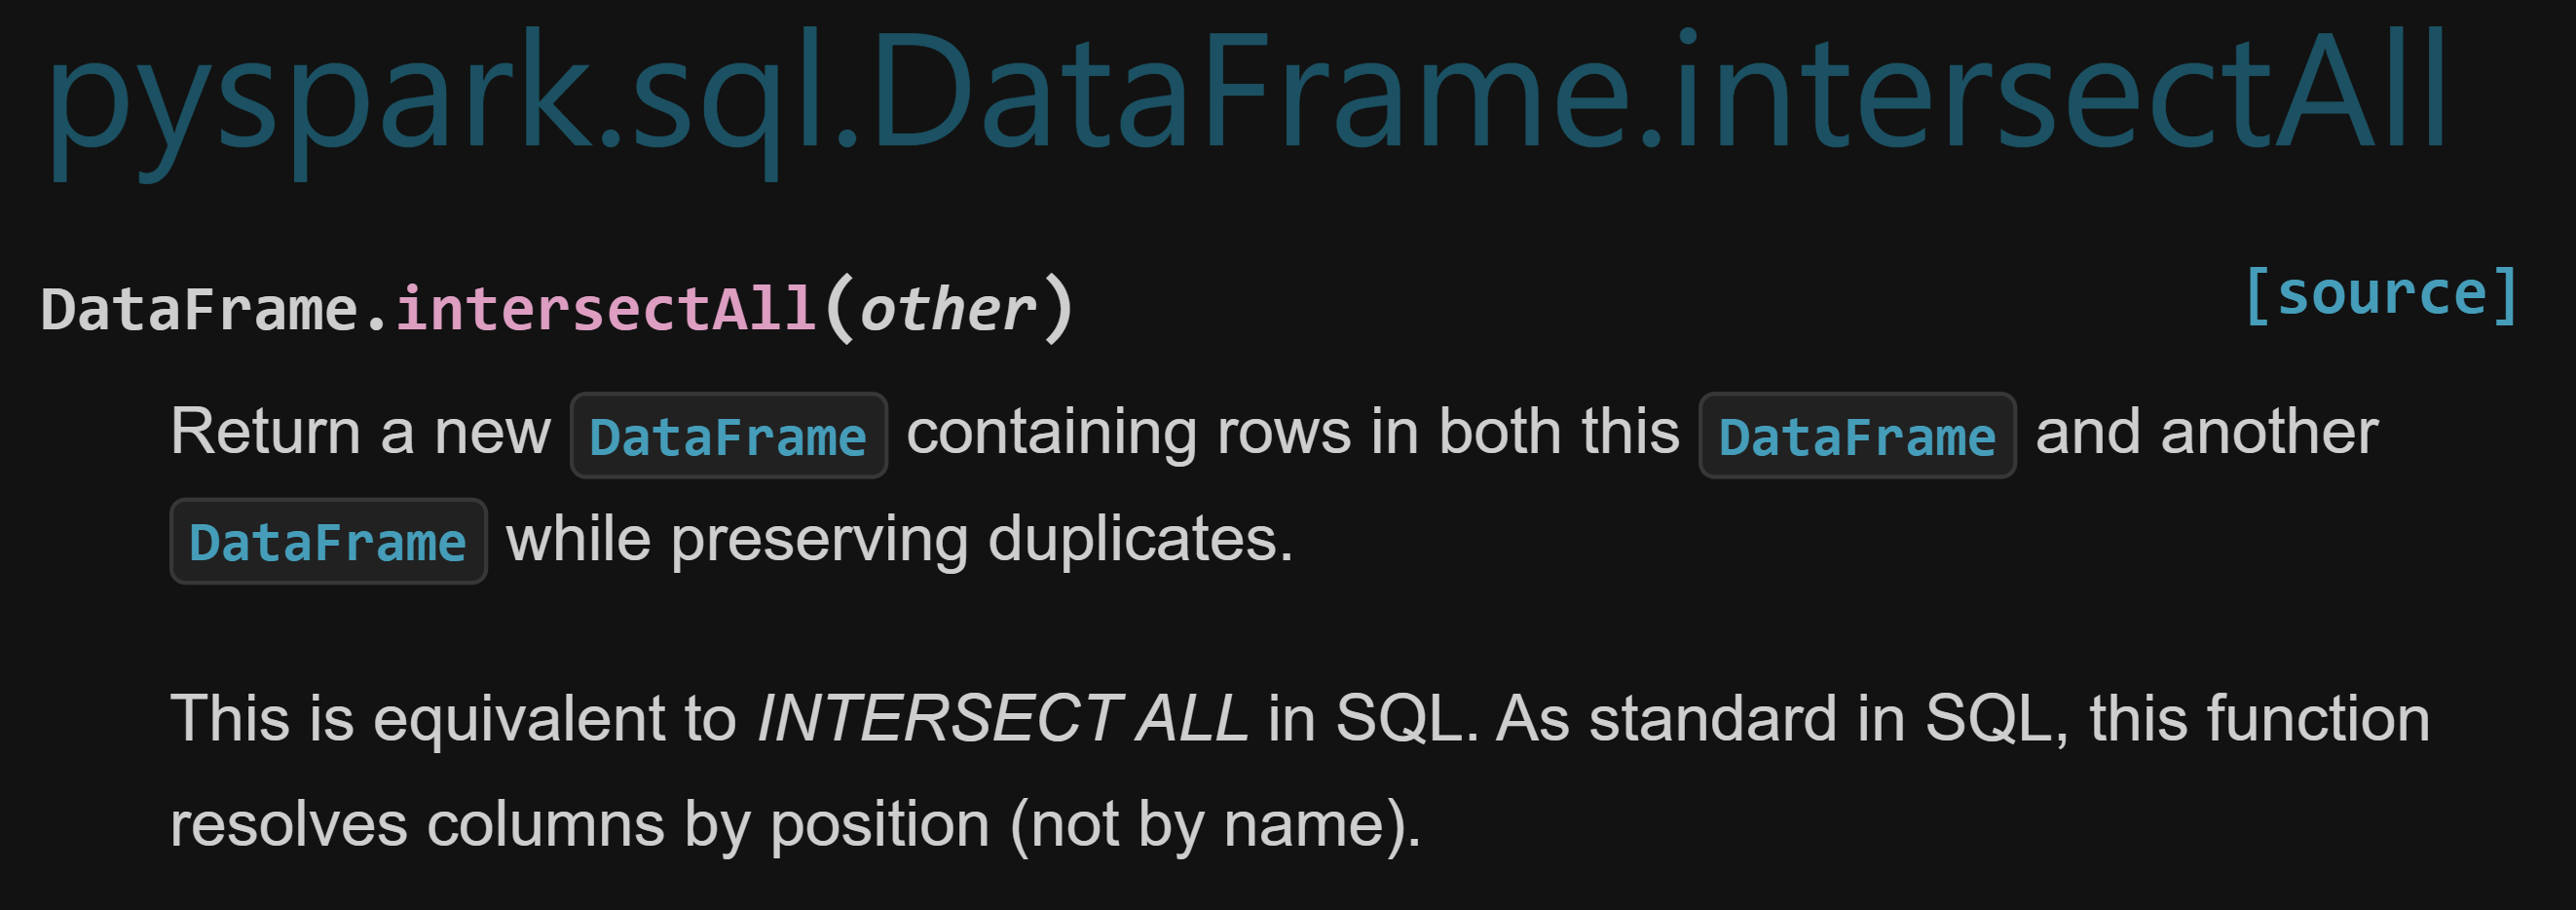

In [33]:
dup_emp1 = [(1,"Smith",-1,"2018","10","M",3000), \
            (1,"Smith",-1,"2018","10","M",3000), \
            (2,"Rose",1,"2010","20","M",4000)]

dup_emp2 = [(1,"Smith",-1,"2018","10","M",3000), \
            (1,"Smith",-1,"2018","10","M",3000), \

            (2,"Rose",1,"2010","20","M",4000), \
            (2,"Rose",1,"2010","20","M",4000), \
            (2,"Rose",1,"2010","20","M",4000)]


dup_empDF1 = spark.createDataFrame(data=dup_emp1, schema = empColumns)
dup_empDF2 = spark.createDataFrame(data=dup_emp2, schema = empColumns)

print("intersect() result:")
d1 = dup_empDF1.intersect(dup_empDF2)

d1.show()

print("intersectAll() result:")
d2 = dup_empDF2.intersectAll(dup_empDF1)

d2.show()





intersect() result:
+------+-----+---------------+-----------+-----------+------+------+
|emp_id| name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+-----+---------------+-----------+-----------+------+------+
|     2| Rose|              1|       2010|         20|     M|  4000|
|     1|Smith|             -1|       2018|         10|     M|  3000|
+------+-----+---------------+-----------+-----------+------+------+

intersectAll() result:
+------+-----+---------------+-----------+-----------+------+------+
|emp_id| name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+-----+---------------+-----------+-----------+------+------+
|     1|Smith|             -1|       2018|         10|     M|  3000|
|     1|Smith|             -1|       2018|         10|     M|  3000|
|     2| Rose|              1|       2010|         20|     M|  4000|
+------+-----+---------------+-----------+-----------+------+------+



In [34]:
df1 = spark.createDataFrame([("a", 1), ("a", 1), ("b", 3), ("c", 4)], ["C1", "C2"])
df2 = spark.createDataFrame([("a", 1), ("a", 1), ("b", 3)], ["C1", "C2"])
result_df = df1.intersectAll(df2).sort("C1", "C2")
result_df.show()


+---+---+
| C1| C2|
+---+---+
|  a|  1|
|  a|  1|
|  b|  3|
+---+---+



**Real-world Use Case**: Finding how many times the same transaction appears in both audit logs, preserving the actual count of occurrences.

In [ ]:
df1 = spark.createDataFrame([("a", 1), ("a", 1), ("b", 3), ("c", 4)], ["C1", "C2"])
df2 = spark.createDataFrame([("a", 1), ("a", 1), ("b", 3)], ["C1", "C2"])
result_df = df1.intersectAll(df2).sort("C1", "C2")
result_df.show()








## 3. SUBTRACT and EXCEPT Operations

### 3.1 subtract() - Finding Differences

The `subtract()` operation returns rows that exist in the first DataFrame but not in the second, removing duplicates.

In [26]:
unique_to_original = empDF.subtract(overlap_empDF)
unique_to_original.show()

+------+-----+---------------+-----------+-----------+------+------+
|emp_id| name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+-----+---------------+-----------+-----------+------+------+
|     5|Brown|              2|       2010|         40|      |    -1|
|     6|Brown|              2|       2010|         50|      |    -1|
|     1|Smith|             -1|       2018|         10|     M|  3000|
|     4|Jones|              2|       2005|         10|     F|  2000|
+------+-----+---------------+-----------+-----------+------+------+



In [35]:
# Using our duplicate examples from earlier
subtract_with_dups = dup_empDF1.exceptAll(dup_empDF2)
print("exceptAll() result:")
subtract_with_dups.show()

# Compare with regular subtract()
subtract_unique = dup_empDF1.subtract(dup_empDF2)
print("subtract() result:")
subtract_unique.show()

exceptAll() result:
+------+----+---------------+-----------+-----------+------+------+
|emp_id|name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+----+---------------+-----------+-----------+------+------+
+------+----+---------------+-----------+-----------+------+------+

subtract() result:
+------+----+---------------+-----------+-----------+------+------+
|emp_id|name|superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+----+---------------+-----------+-----------+------+------+
+------+----+---------------+-----------+-----------+------+------+



In [36]:
df1 = spark.createDataFrame(
        [("a", 1), ("a", 1), ("a", 1), ("a", 2), ("b",  3), ("c", 4)], ["C1", "C2"])
df2 = spark.createDataFrame([("a", 1),("a", 1),("b", 3)], ["C1", "C2"])
df1.exceptAll(df2).show()


+---+---+
| C1| C2|
+---+---+
|  a|  1|
|  a|  2|
|  c|  4|
+---+---+

